In [1]:
%load_ext autoreload
%autoreload 2

import inspect
import itertools

import numpy as np
import pandas as pd
from scipy.signal import resample
import matplotlib.pyplot as plt

import concurrent.futures
from collections import defaultdict

#import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

import sys
sys.path.append("../LorenzCaosTest")
from Test_Chaos_noparallel import caostest10_noparallel 

from sum_time_series import (generate_sinusoidal_series, rndm, generate_power_law_series_negative, generate_inversely_related_series, 
                             calculate_spectral_entropy, perform_fft, identify_peaks, 
                             calculate_f1_score, calculate_f1_score_corrected, analyze_spectrum_detail, plot_exp_distrib,
                            parallel_generate_series
                            )

from prove import res, plot_all

import networkx as nx
import nolds
from statsmodels.tsa.stattools import adfuller
from scipy.stats import skew, kurtosis

from properties_time_series import calc_autocorrelation, calc_ret, calc_log_ret, calc_volatility, plot_distribution
from calc_every_combination import build_graph, carica_predecessori_ricorsivi, disegna_grafo, disegna_sottografo, esegui_funzioni_sottografo
from calc_every_combination import debug_var

ModuleNotFoundError: No module named 'statsmodels'

esponente teorico ampiezze 4.999999999999449e-05


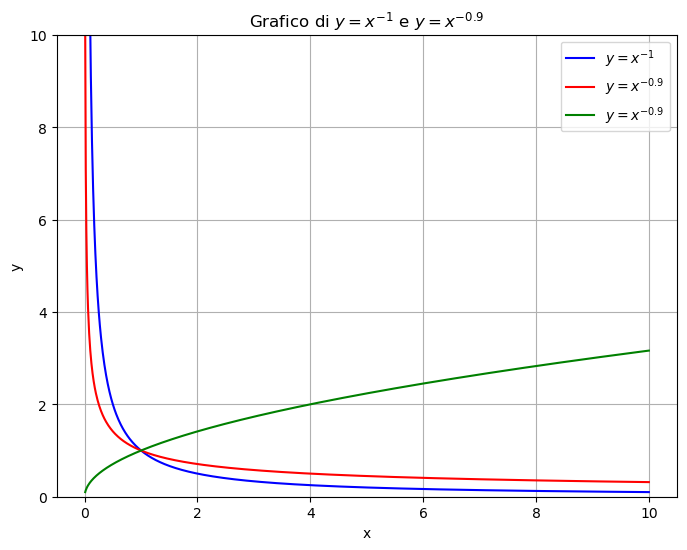

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Definire l'intervallo di x evitando la divisione per zero
x = np.linspace(0.01, 10, 1000)

# Calcolare le funzioni
exp = -1.0001
y1 = x ** exp
teo = (- 1 - exp) / 2
print(f"esponente teorico ampiezze {teo}")
amp = -0.5 
y2 = x ** amp
yy = y1 ** amp

# Creare il grafico
plt.figure(figsize=(8, 6))
plt.plot(x, y1, label=r"$y = x^{-1}$", color="blue")
plt.plot(x, y2, label=r"$y = x^{-0.9}$", color="red")
plt.plot(x, yy, label=r"$y = x^{-0.9}$", color="green")

# Impostare etichette e titolo
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(0,10)
#plt.xscale('log')
#plt.yscale('log')
plt.title("Grafico di $y = x^{-1}$ e $y = x^{-0.9}$")
plt.legend()
plt.grid(True)

# Mostrare il grafico
plt.show()


In [15]:
series_length = 360000  # Length of each series
sampling_freq = 1 # Sampling frequency in Hz

n_series_range = range(1001, 1500, 1500)   # range(1001, 1, -790)

# Numero di ripetizioni per ogni valore intero nel range
num_repetitions = 1

In [11]:
list(n_series_range)

[1001]

# Serie con spettro a legge di potenza

In [16]:
exponent=-1.0001
freq_range=(0.000001, 500)
#amp_range=(0.0001, 100)
C=1
serie_generate, freqs_generate, amps_generate = parallel_generate_series(n_series_range, num_repetitions, series_length, sampling_freq, exponent, freq_range, C)

In [17]:
serie_generate.keys()

dict_keys([1001])

In [ ]:
serie_generate = np.load('serie_generate_198_360000_1.npy', allow_pickle=True).item()

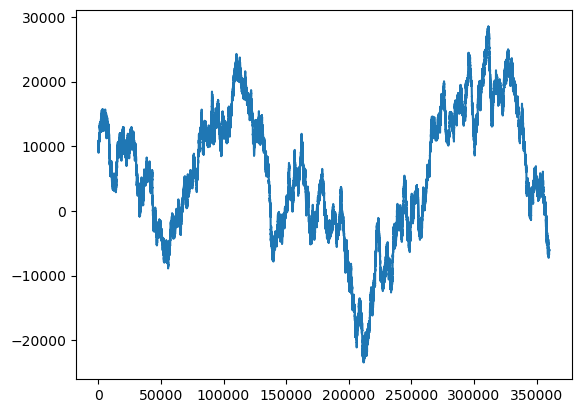

In [18]:
plt.plot(serie_generate[1001][0])#[:10000])

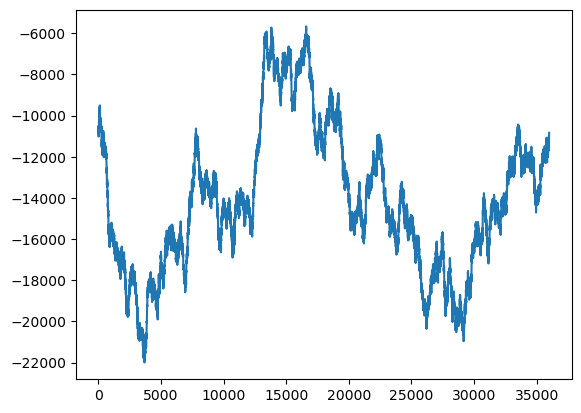

In [11]:
np.save('serie_generate_120001_36000_1.npy', serie_generate)

### Misura la complessità

In [4]:
def get_measures(composite_series, sampling_freq):
    
    entropy_value = calculate_spectral_entropy(composite_series, sampling_freq)
    serie_ridotta = composite_series[::15]
    chaos_value = caostest10_noparallel(serie_ridotta)    
    
    # Eseguire la FFT sulla serie composta
    frequencies, fft_magnitude = perform_fft(composite_series, sampling_freq)
    # Calcolare F1-score, precisione e richiamo
    f1_score, precision, recall, identified_frequencies = calculate_f1_score_corrected(original_frequencies, frequencies, fft_magnitude, height=0.01)
    
    return entropy_value, chaos_value, f1_scores

In [4]:
spectral_entropies_repetitions = []
chaos_ripetizioni = []
average_f1_scores = []

serie_generate = {}

for n in n_series_range:
    entropies = []
    chaoss = []
    f1_scores = []
    serie_generate[n] = []
    
    for _ in range(num_repetitions):
        # Generate sinusoidal time series
        #series, _, _ = generate_sinusoidal_series(n, series_length, sampling_freq)
        composite_serie, ts, original_frequencies, _ = generate_inversely_related_series(n, series_length, sampling_freq, exponent=-1.5, freq_range=(0.00001, 0.5), amp_range=(0.01, 100), C=3)        
        
        serie_generate[n].append(composite_serie)

        # Calculate the spectral entropy of the composite series
        #entropy_value, chaos_value, f1_scores = get_measures(composite_series, sampling_freq):
        entropy_value, chaos_value, f1_score = 0,0,0
        entropies.append(entropy_value)
        chaoss.append(chaos_value)
        f1_scores.append(f1_score) 
        

    # Calcolare la media delle entropie per ogni numero di serie
    average_entropy = np.mean(entropies)
    spectral_entropies_repetitions.append(average_entropy)
    
    avg_caos = np.mean(chaoss)
    chaos_ripetizioni.append(avg_caos)
    
    # Calcolare la media delle entropie per ogni numero di serie
    average_f1 = np.mean(f1_scores)
    average_f1_scores.append(average_f1)

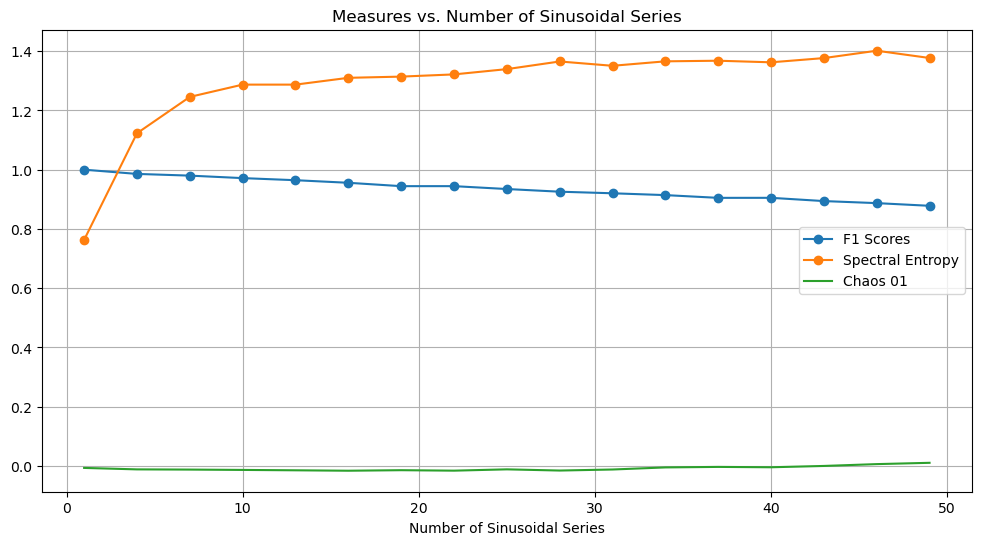

In [4]:
# Tracciare l'F1-score medio al variare del numero di serie sommate
plt.figure(figsize=(12, 6))
plt.plot(n_series_range, average_f1_scores, marker='o', label='F1 Scores')
plt.plot(n_series_range, spectral_entropies_repetitions, marker='o', label='Spectral Entropy')
plt.plot(n_series_range, chaos_ripetizioni , label='Chaos 01')
plt.xlabel('Number of Sinusoidal Series')
plt.title('Measures vs. Number of Sinusoidal Series')
plt.grid(True)
plt.legend()
plt.show()

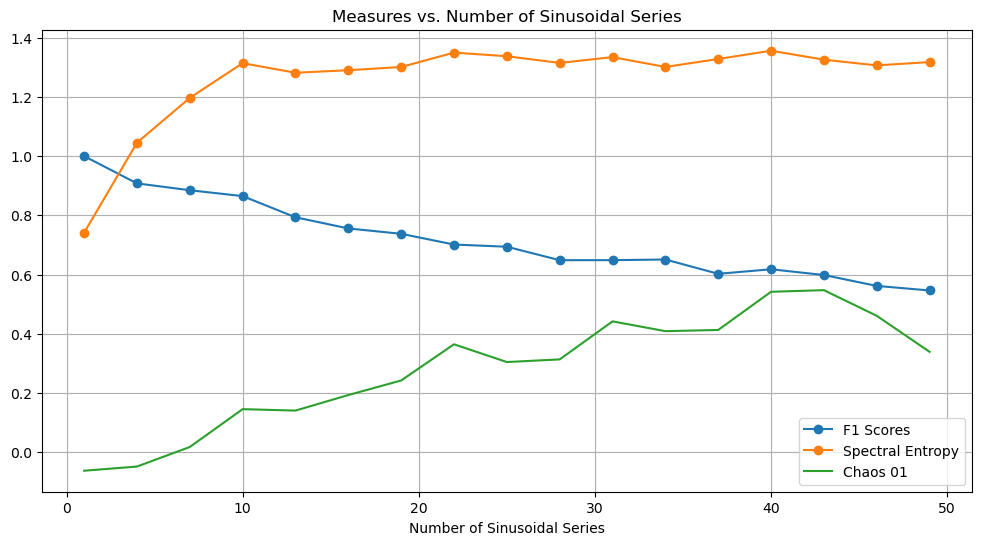

# Plot serie

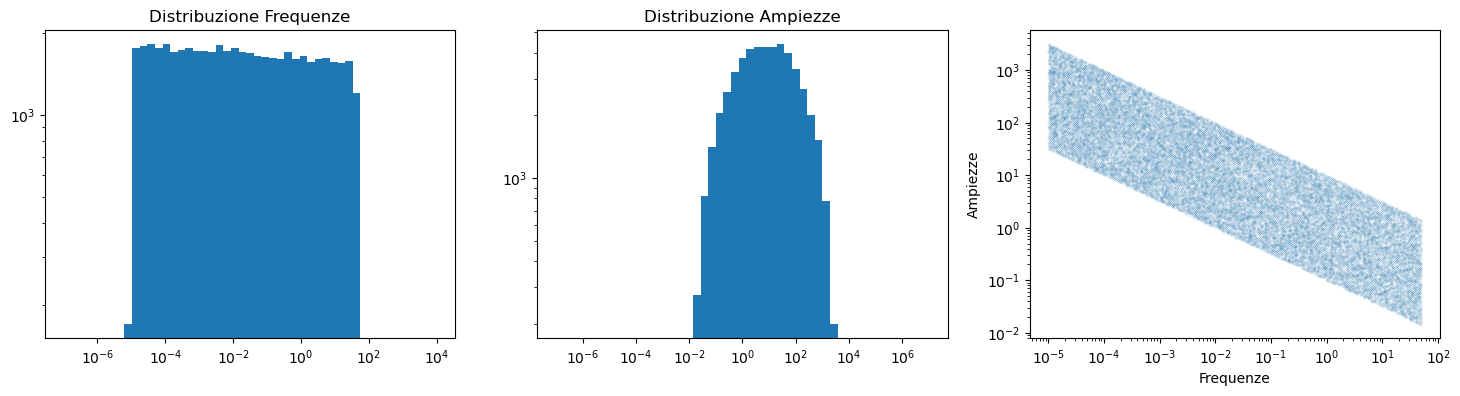

In [6]:
i=1001
tutte_frequenze = np.array(freqs_generate[i]).ravel()
minf, maxf = min(tutte_frequenze), max(tutte_frequenze)
tutte_ampiezze = np.array(amps_generate[i]).ravel()


fig, ax = plt.subplots(1,3, figsize=(18,4))
# Definisci i bin su una scala logaritmica
log_bins1 = np.logspace(np.log10(1e-7), np.log10(1e4), 50)
log_bins2 = np.logspace(np.log10(1e-7), np.log10(1e7), 50)
    
ax[0].hist(tutte_frequenze, bins=log_bins1)  #, amps_generate[49], '.', label='Spectral Magnitude')
ax[0].set_title("Distribuzione Frequenze")
ax[1].hist(tutte_ampiezze, bins=log_bins2)
ax[1].set_title("Distribuzione Ampiezze")
ax[2].plot(tutte_frequenze, tutte_ampiezze, '.', label='Spectral Magnitude', markersize=0.1)
ax[2].set_xlabel('Frequenze')
ax[2].set_ylabel('Ampiezze')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[2].set_xscale('log')
ax[2].set_yscale('log')

plt.show()

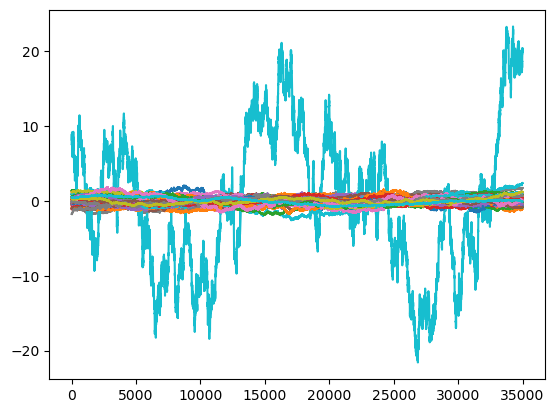

In [55]:
i = 1001
ss = np.array(serie_generate[i]).T[:35000,:]
normalized = (ss- np.mean(ss, axis=0)) / (np.max(ss, axis=0)) 
plt.plot(normalized);

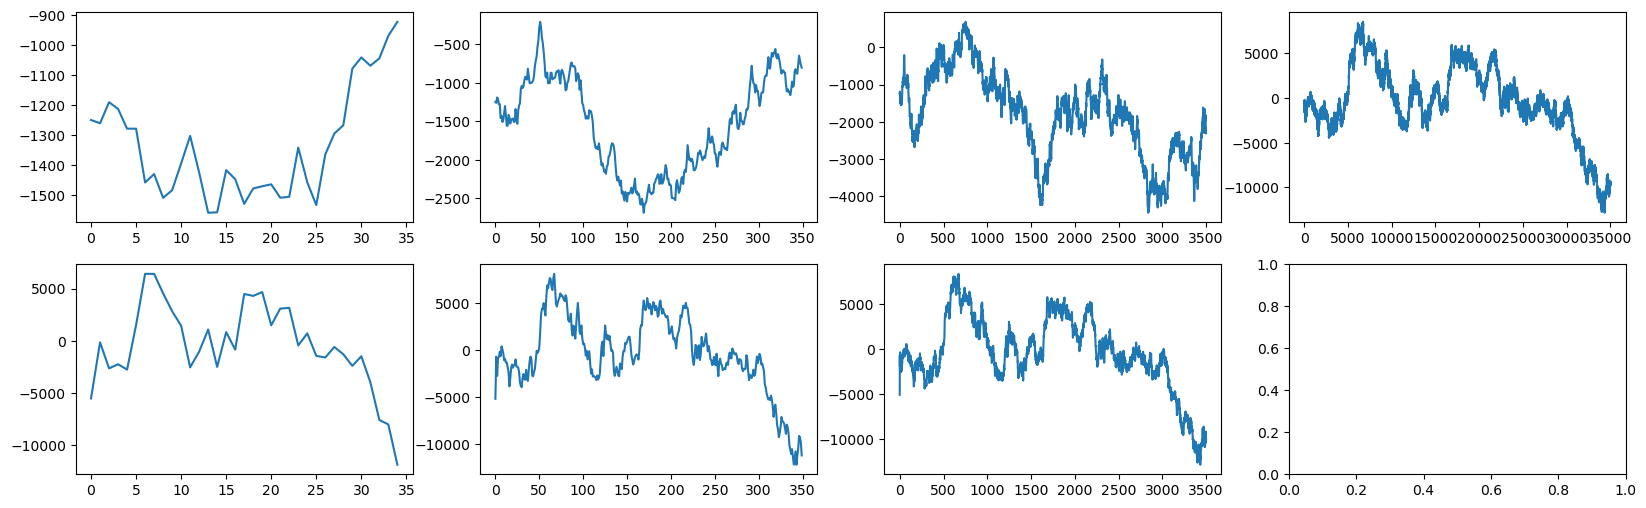

In [8]:
s = np.array(serie_generate[i]).T[:35000,1]
fig, ax = plt.subplots(2, 4, figsize=(20,6))
ax[0,0].plot(s[:35])
ax[0,1].plot(s[:350])
ax[0,2].plot(s[:3500])
ax[0,3].plot(s[:35000])
resampled35 = resample(s, num=35)
resampled350 = resample(s, num=350)
resampled3500 = resample(s, num=3500)
resampled35000 = resample(s, num=35000)
ax[1,0].plot(resampled35)
ax[1,1].plot(resampled350)
ax[1,2].plot(resampled3500)
#ax[1,3].plot(resampled35000)

# variazioni

In [4]:
exponent=-0.9

#amp_range=(0.0001, 100)
#C = [1, 1e+2, 1e+4, 1e+6, 1e+8]
C = 1
#freq_range = [(0.00001, 50), (0.000001, 500), (0.0001, 1), (0.0001, 0.1), (0.001, 1)]
freq_range=(1e-6, 500)
exp_range = [-0.7, -0.85, -0.999, -1.001, -1.15, -1.3]

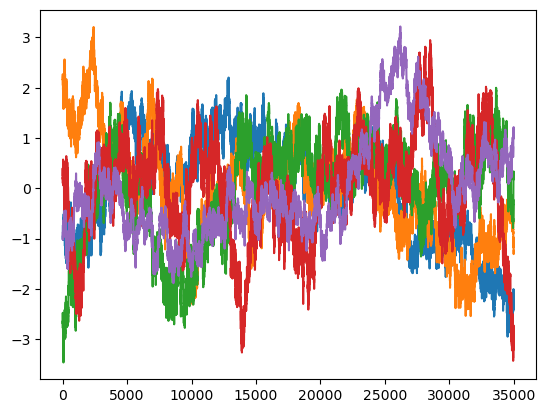

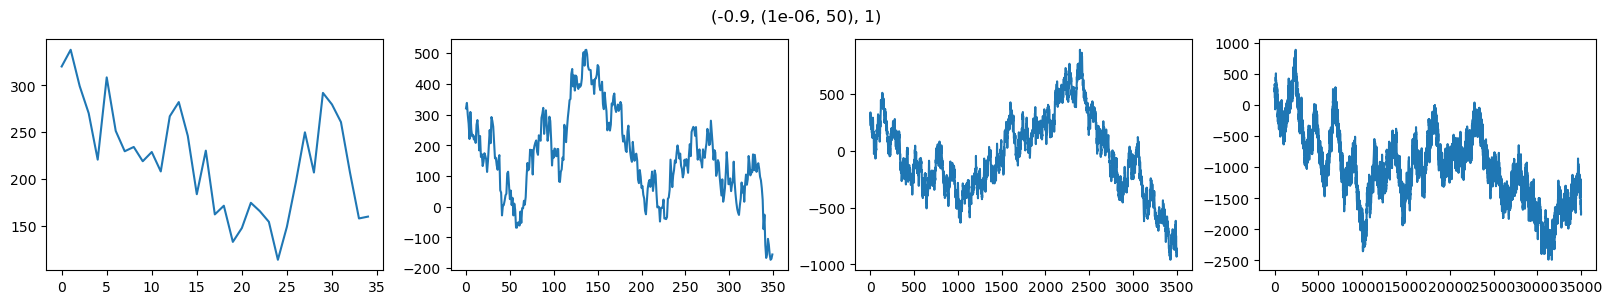

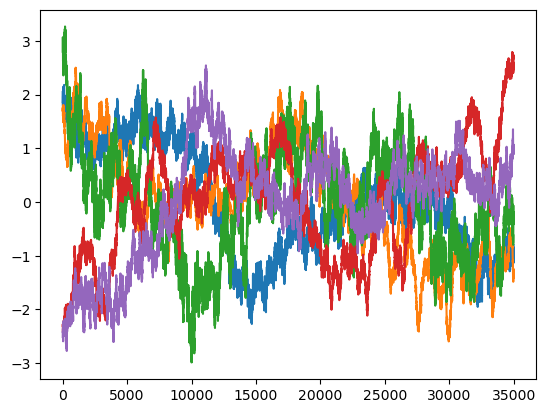

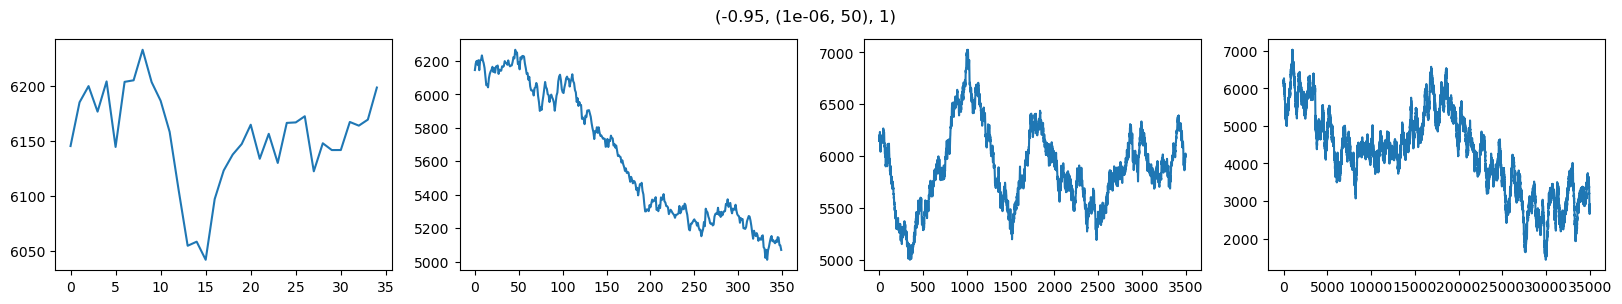

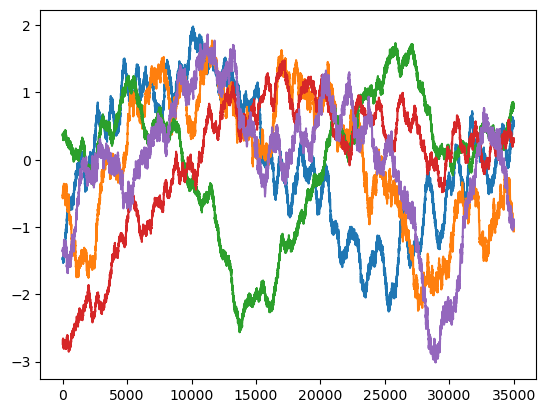

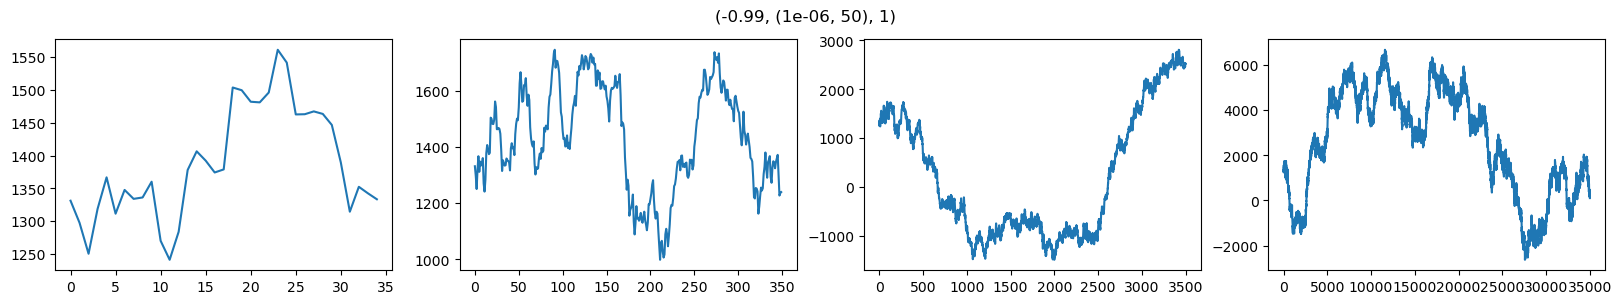

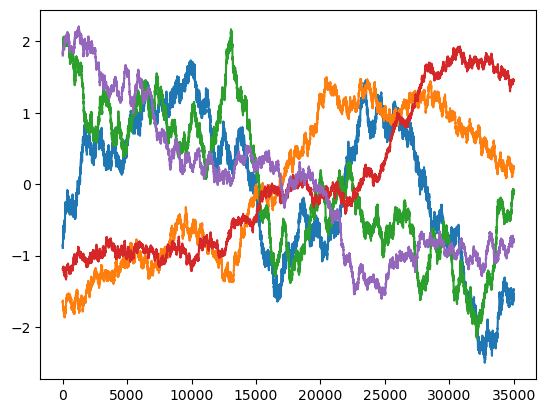

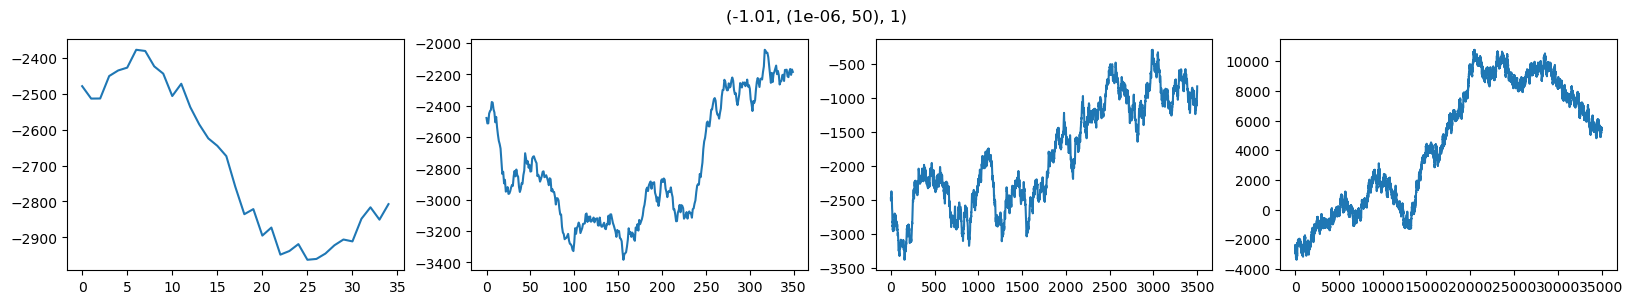

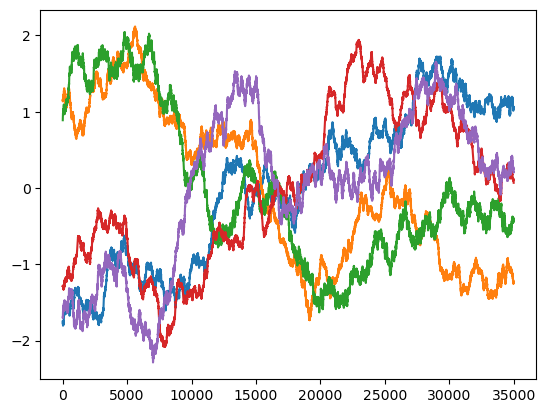

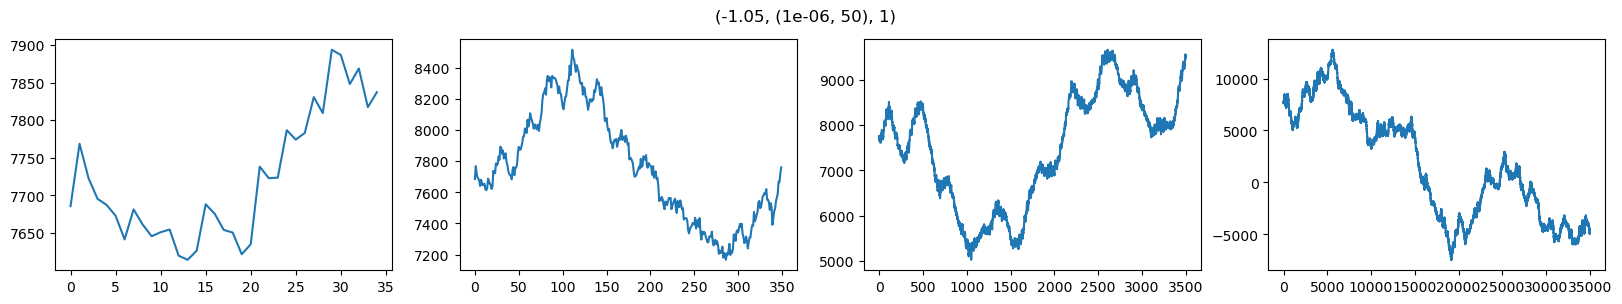

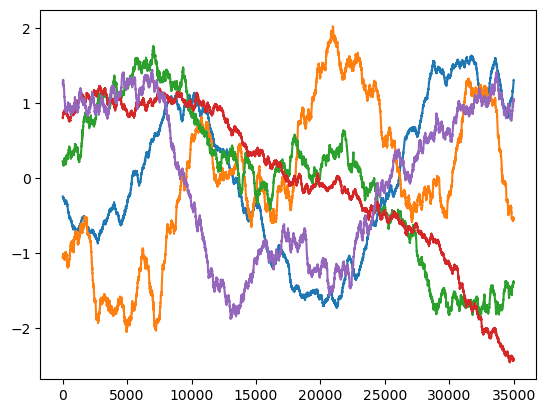

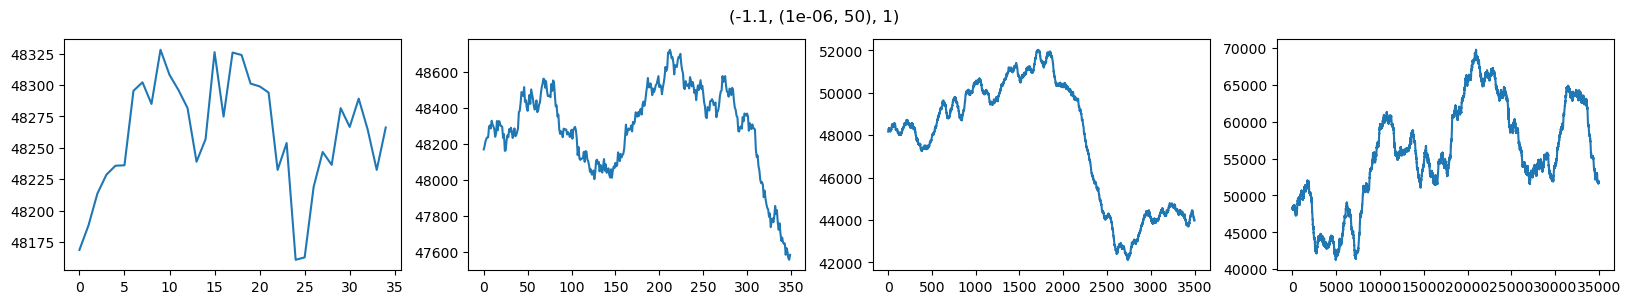

In [65]:
for e in exp_range:
    res((e, freq_range, C))

In [6]:
############### 1 Distribuzione dei log-returns e Kurtosi, skewness (non log?)
# 2 cluster di volatilità tramite autocorrelazione dei valori assoluto dei rendimenti
# 3 assenza di autocorrelazione dei rendimenti
# 4 asimmetria volatilità/rendimento
# 5 autocorrelazione della volatilità
# 6 multifrattalità
# 7 non stazionarietà dei returns


# Stime di invarianza di scala

/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/scipy/stats/stats.py:1107: RuntimeWarning: Mean of empty slice.
  mean = a.mean(axis, keepdims=True)
/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/numpy/core/_methods.py:181: RuntimeWarning: invalid value encountered in true_divide
  ret = um.true_divide(
/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/scipy/stats/stats.py:1216: RuntimeWarning:

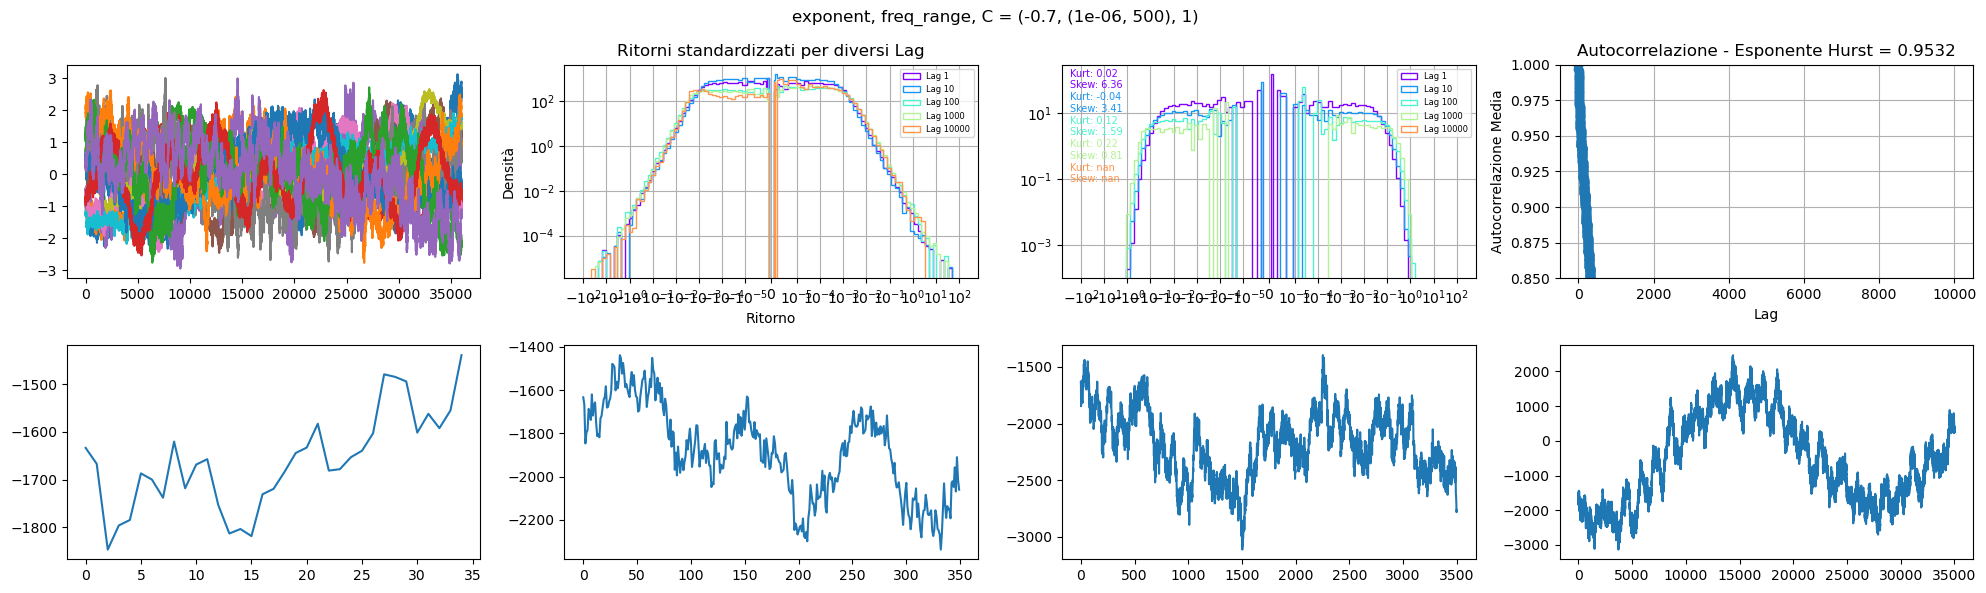

/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


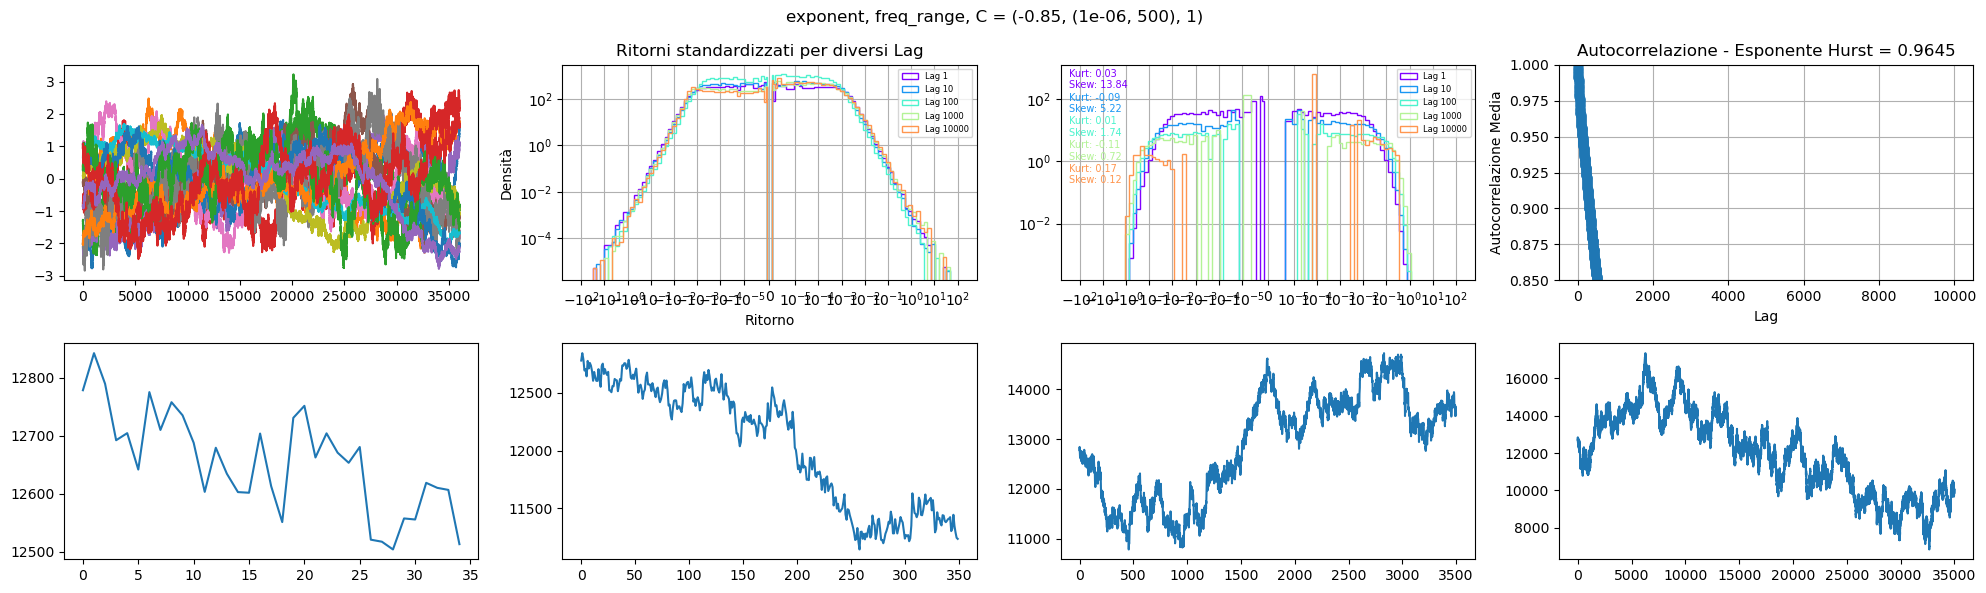

/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


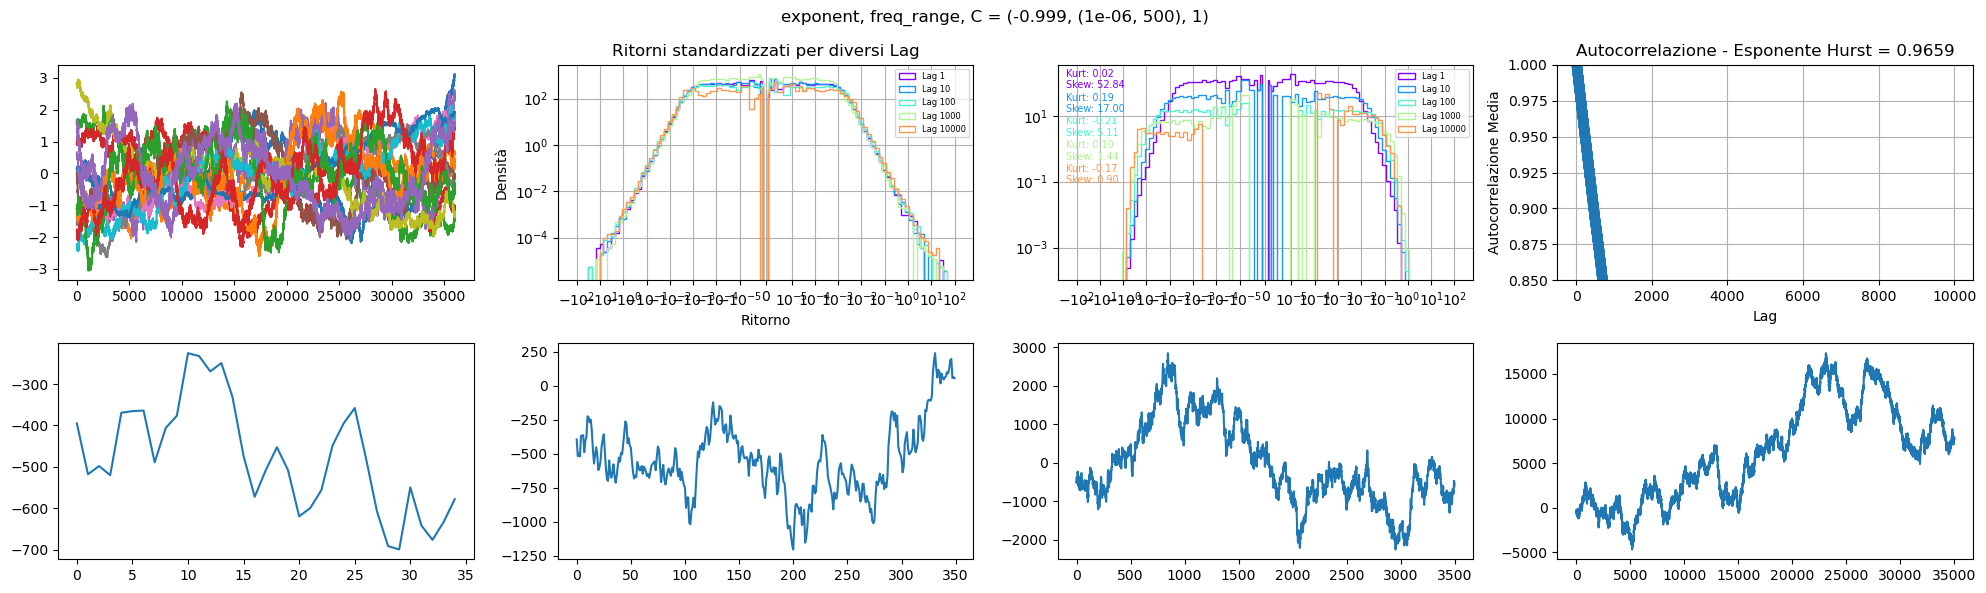

/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


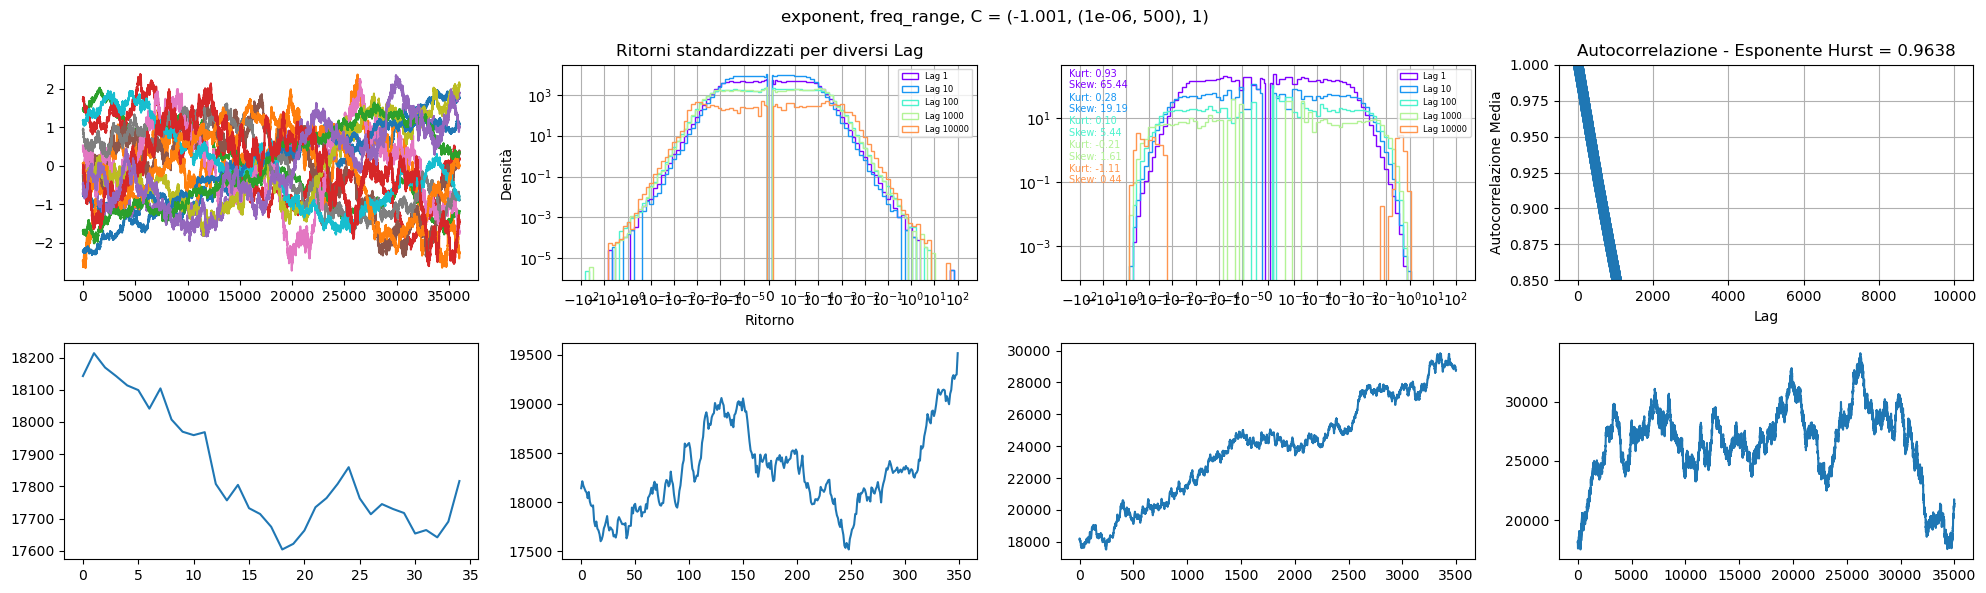

/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


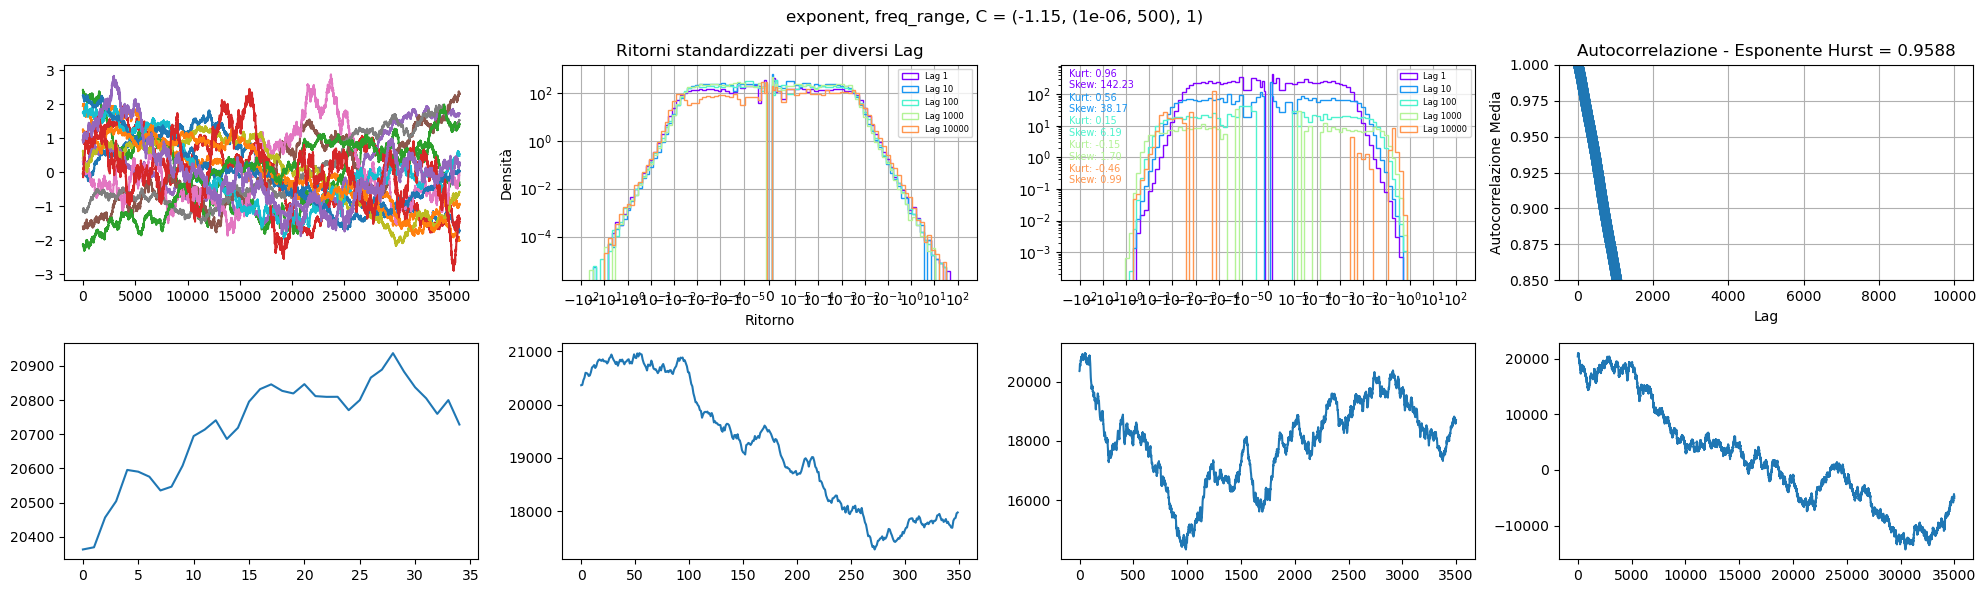

/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


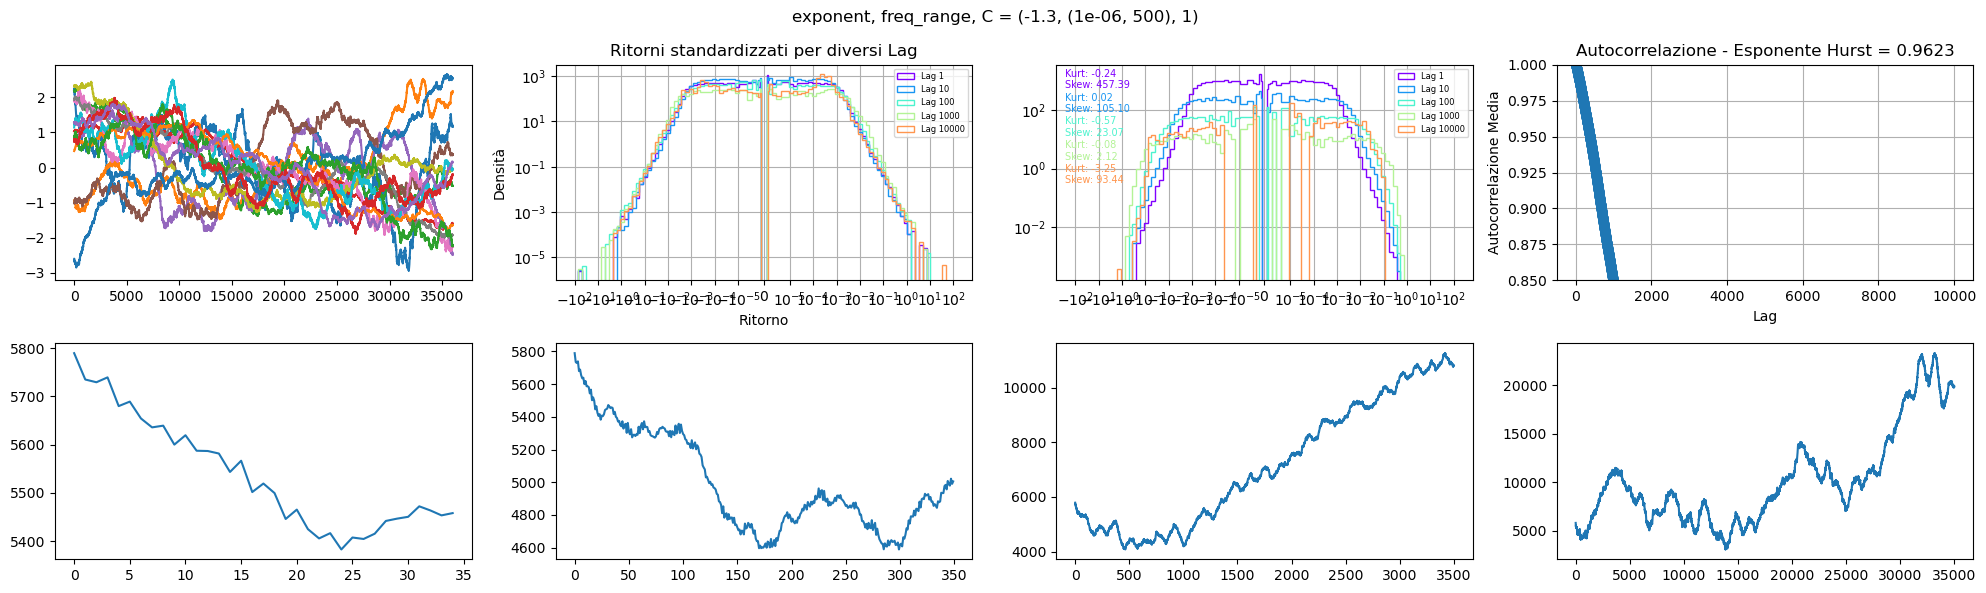

In [20]:
for e in exp_range:
    m, lags = res((e, freq_range, C), (n_series_range, num_repetitions, series_length, sampling_freq))
    plot_all(m, lags)

In [9]:
np.save('serie_generate', serie_generate)

# Prove grafo computazionale

### definizione link e plot

In [5]:
G = build_graph()

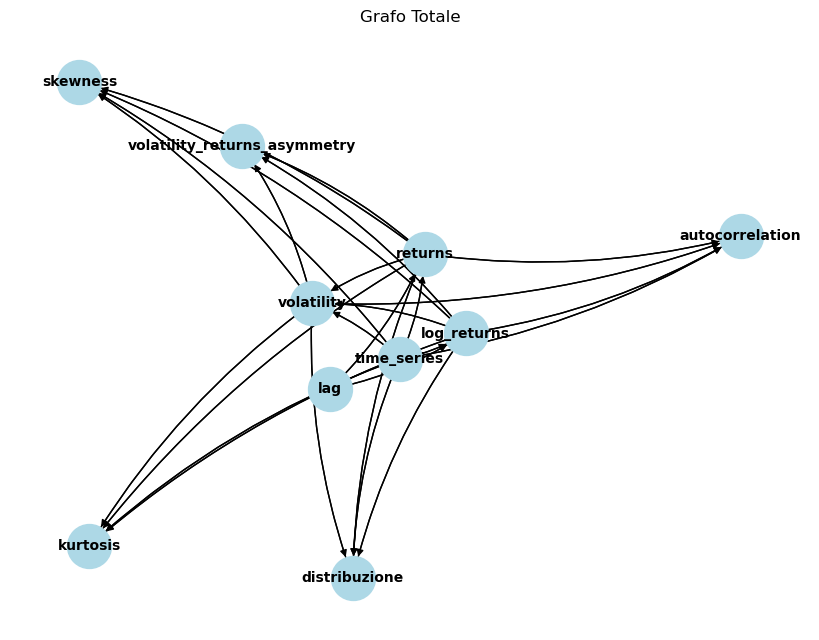

In [6]:
disegna_grafo(G)

## esegui_funzioni_sottografo

In [85]:
G.nodes["time_series"]["risultati_calcolati"] = {
    "time_series":  np.array(serie_generate[1001])[0:3,:3000]
}


esegui_funzioni_sottografo(G)

/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/daniele/anaconda3/envs/TSenv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [14]:
isinstance(G.nodes['log_returns']['risultati_calcolati'], dict)

True

## Mostra risultati

In [48]:
plot_distribution

<function properties_time_series.plot_distribution(array, ax, **kwargs)>

In [178]:
def separa_nome_e_valore(dizionario_risultati):
    estratti = []
    for chiave, valore in dizionario_risultati.items():
        # Supponiamo che il formato sia del tipo 'parametro_valore1_valore2'
        parti = chiave.split('_')
        nome_parametro = parti[-2]
        valori_parametri = parti[-1:]  # Può contenere uno o più valori
        estratti.append({
            'Nome_Parametro': nome_parametro,
            'Valori_Parametri': valori_parametri,
            'Variabile': valore
        })
    return estratti

def mostra_risultati_grafo(grafo, separatore='§'):
    nodi = list(nx.topological_sort(grafo))
    num_nodi = len(nodi)
    fig, axes = plt.subplots(num_nodi, 1, figsize=(10, 5 * num_nodi))

    # Se c'è un solo nodo, axes non sarà una lista, quindi trasformiamolo in una lista
    if num_nodi == 1:
        axes = [axes]


    for ax, nodo in zip(axes, nodi):
        print(f"\n\n nodo {nodo}")
        if 'risultati_calcolati' in grafo.nodes[nodo]:
            risultati = grafo.nodes[nodo]['risultati_calcolati']
            #print(risultati)

           # Creare una struttura di dizionari annidati per raggruppare i risultati
            risultati_aggregati = defaultdict(lambda: defaultdict(list))

            for chiave, valore in risultati.items():               
                # Dividi la chiave per separatore per ottenere tutte le parti del nome del parametro
                parti = chiave.split(separatore)
                if len(parti) == 1:
                    # Se il nodo ha una sola parte (input di partenza), saltiamo
                    continue
                nome_parametro = parti[0]
                combinazioni_parametri = parti[1:]
                #print(f"combinazioni_parametri {combinazioni_parametri}")
                

                 # Costruire una struttura annidata che consenta l'aggregazione per variabili chiave
                nodo_corrente = risultati_aggregati[nome_parametro]
                for parte in combinazioni_parametri[:-1]:
                    #print(f"Debug - nodo_corrente prima di aggiornare: {nodo_corrente}, parte: {parte}")
                    if parte not in nodo_corrente or not isinstance(nodo_corrente[parte], dict):
                        nodo_corrente[parte] = defaultdict(list)
                    nodo_corrente = nodo_corrente[parte]
                    
                #print(f"Debug - nodo_corrente finale prima di aggiungere valore: {nodo_corrente}")
                debug_var(valore)
                nodo_corrente[combinazioni_parametri[-1]].extend(valore)
                #.extend(valore if isinstance(valore, list) else [valore])

            #print(f"risultati_aggregati {risultati_aggregati}")
            # Funzione per appiattire i risultati annidati e plottarli
            def plot_risultati_annidati(ax, nodo_corrente, etichetta_base=""):
                for chiave, valore in nodo_corrente.items():
                    nuova_etichetta = f"{etichetta_base} {chiave}".strip()
                    
                    if isinstance(valore, dict):
                        plot_risultati_annidati(ax, valore, nuova_etichetta)
                    else:
                        print(f"nuova_etichetta {nuova_etichetta}")
                        #print(f"valore: {valore}")
                        debug_var(valore)
                        plot_distribution(np.array(valore).T, ax=ax, label=nuova_etichetta)

            # Plottare tutti i risultati aggregati
            plot_risultati_annidati(ax, risultati_aggregati)

               

            ax.set_title(f"Risultati per il nodo: {nodo}")
            ax.legend()
            
           
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.




 nodo time_series


 nodo lag


 nodo returns


 nodo log_returns


 nodo volatility


 nodo autocorrelation


 nodo distribuzione


 nodo kurtosis


 nodo skewness


 nodo volatility_returns_asymmetry


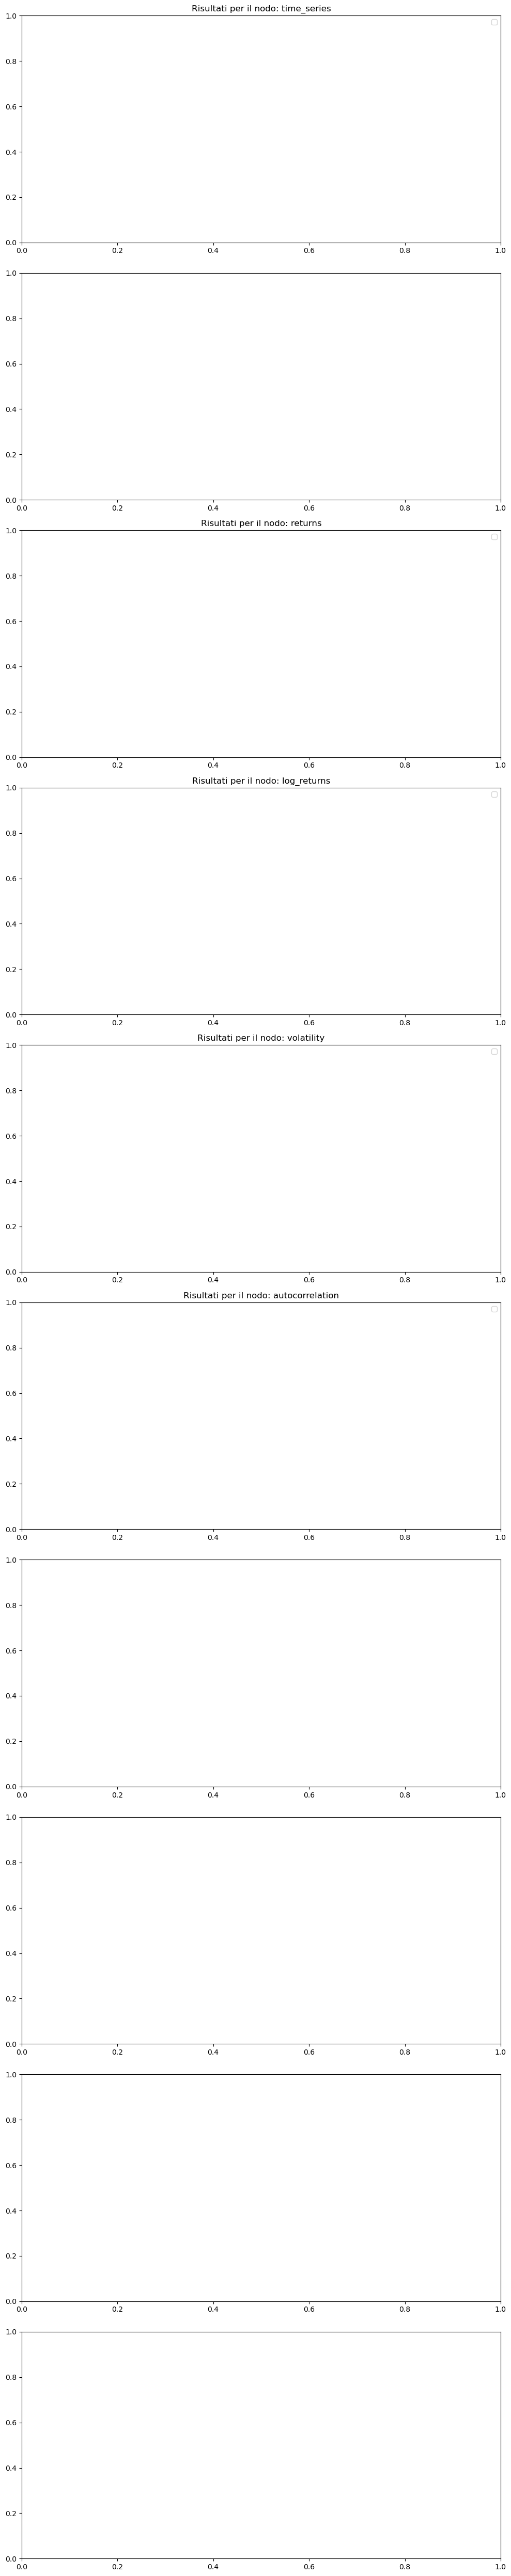

In [63]:
mostra_risultati_grafo(G)

In [72]:
risultati = G.nodes['log_returns']['risultati_calcolati']
estratti = separa_nome_e_valore(risultati)
for item in estratti:
    print(f"Nome Parametro: {item['Nome_Parametro']}, Valori Parametri: {item['Valori_Parametri']}, Valore: {item['Valore']}")

Nome Parametro: lag, Valori Parametri: ['1'], Valore: [[-0.07331926  0.05267097 -0.02826074  0.01040168  0.11120227 -0.00648598
   0.00311774  0.11986838 -0.13103667 -0.10100628  0.1174165  -0.09908489]
 [ 0.01780091 -0.03516074  0.02878107  0.0086718   0.08564884  0.02077272
  -0.05783467  0.05416476 -0.08662177 -0.00728201 -0.01477315 -0.02161475]]
Nome Parametro: lag, Valori Parametri: ['2'], Valore: [[-0.02064829  0.02441023 -0.01785906  0.12160395  0.10471628 -0.00336824
   0.12298612 -0.01116829 -0.23204295  0.01641022  0.01833161]
 [-0.01735983 -0.00637967  0.03745287  0.09432064  0.10642156 -0.03706195
  -0.00366991 -0.03245701 -0.09390378 -0.02205516 -0.03638789]]
Nome Parametro: lag, Valori Parametri: ['3'], Valore: [[-0.04890903  0.03481191  0.09334321  0.11511796  0.10783403  0.11650014
  -0.00805055 -0.11217457 -0.11462645 -0.08267467]
 [ 0.01142124  0.00229213  0.12310171  0.11509336  0.04858689  0.01710281
  -0.09029168 -0.03973902 -0.10867692 -0.0436699 ]]
Nome Parametr

In [60]:
risultati = {}
for nodo in G.nodes:
    if 'risultati_calcolati' in G.nodes[nodo]:
        for chiave, valore in G.nodes[nodo]['risultati_calcolati'].items():
            #risultati.append({'Nodo': nodo, 'Nome_Risultato': chiave, 'Valore': valore})
            if (nodo, chiave) not in risultati:
                risultati[(nodo, chiave)] = []
            risultati[(nodo, chiave)].extend(valore)

#print(risultati)
df_risultati = pd.DataFrame(risultati)
df_risultati.columns = pd.MultiIndex.from_tuples(df_risultati.columns, names=['Nodo', 'Nome_Risultato'])

ValueError: All arrays must be of the same length

### esegui

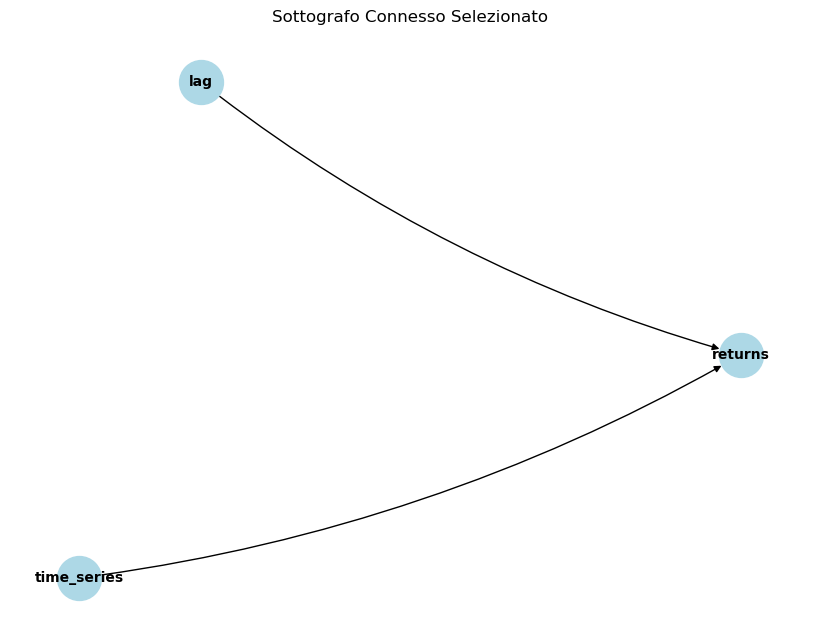

In [167]:
# Carica un sottoinsieme connesso del grafo
elementi_selezionati = ['returns', 'autocorrelation', 'kurtosis']
elementi_selezionati = ['returns']

try:
    sottografo = carica_predecessori_ricorsivi(G, elementi_selezionati)
    disegna_sottografo(G, sottografo)
    esegui_funzioni_sottografo(sottografo)
    #for nodo, risultato in risultati.items():
    #    print(f"Calcolati risultati per {nodo}")
except ValueError as e:
    print(e)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 



 nodo lag


 nodo time_series


 nodo returns
Tipo: Numpy Array, Shape: (3, 2999)
Tipo: Numpy Array, Shape: (3, 2998)
Tipo: Numpy Array, Shape: (3, 2997)
Tipo: Numpy Array, Shape: (3, 2995)
Tipo: Numpy Array, Shape: (3, 2990)
nuova_etichetta returns time_series lag_1
Tipo: Lista, Lunghezza: 3
Tipo: Numpy Array, Shape: (2999,)
Tipo: Numpy Array, Shape: (2999,)
Tipo: Numpy Array, Shape: (2999,)
nuova_etichetta returns time_series lag_2
Tipo: Lista, Lunghezza: 3
Tipo: Numpy Array, Shape: (2998,)
Tipo: Numpy Array, Shape: (2998,)
Tipo: Numpy Array, Shape: (2998,)
nuova_etichetta returns time_series lag_3
Tipo: Lista, Lunghezza: 3
Tipo: Numpy Array, Shape: (2997,)
Tipo: Numpy Array, Shape: (2997,)
Tipo: Numpy Array, Shape: (2997,)
nuova_etichetta returns time_series lag_5
Tipo: Lista, Lunghezza: 3
Tipo: Numpy Array, Shape: (2995,)
Tipo: Numpy Array, Shape: (2995,)
Tipo: Numpy Array, Shape: (2995,)
nuova_etichetta returns time_series lag_10
Tipo: Lista, Lunghezza: 3
Tipo: Numpy Array, Shap

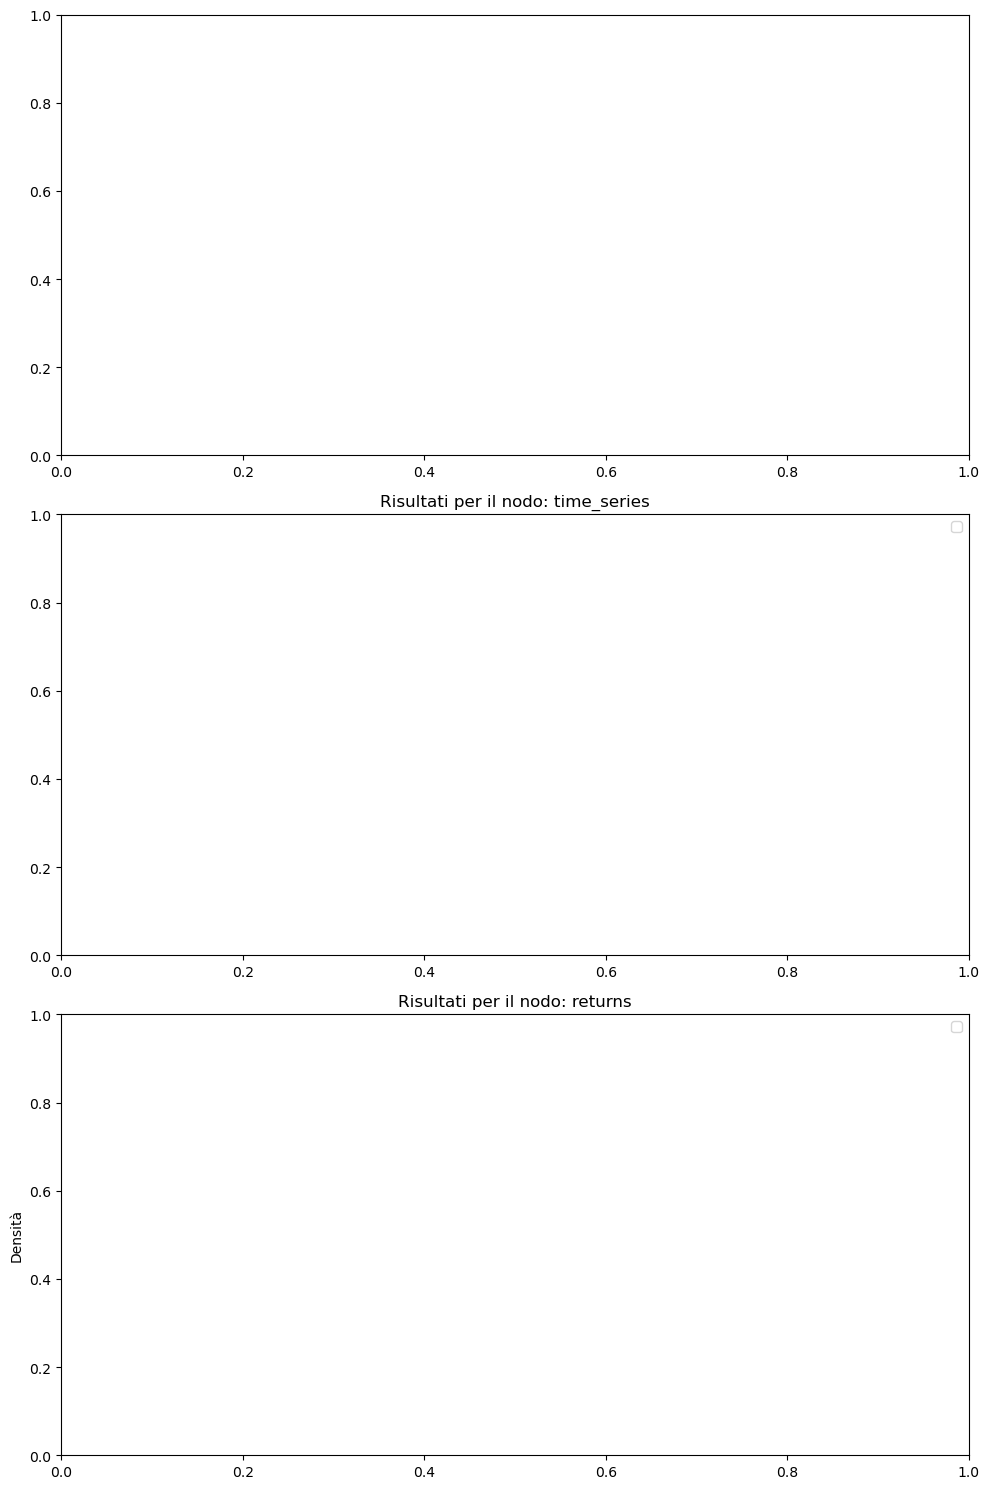

In [179]:
mostra_risultati_grafo(sottografo)